# QF 627 Programming and Computational Finance
## Lesson 05 | Rule-Based Algorithmic Trading: `Momentum` & `Mean-Reversion` Strategies

> Hi Team 👋

> Thank you for opening the script 🙂 So far, we have built a solid foundation in computational programming with Python for handling financial time series. We have also practiced agile exploratory data analysis using the grammar of graphics framework (lets-plot), and explored the fundamentals of rule-based algorithmic trading and backtesting.

> In this lesson, we will move step by step through writing and implementing rule-based algorithmic trading strategies.

> We learn how algorithmic trading strategies can be structured around well-defined rules, specifically using momentum and mean-reversion principles. We will look at how these strategies are conceptualized, implemented, and assessed in live market conditions. Emphasis is placed on creating clear, evidence-based guidelines for both entry and exit signals, ensuring trade consistency, and understanding risk management considerations crucial to industry practitioners.

    Algorithmic decision-making is a frequent topic of discussion in organizations, yet many still struggle to apply it effectively in practice. This session highlights the power of algorithmic thinking by contrasting it with intuition-based decision-making. We will learn about AI/ML applications beyond marketing and operations—including financial decision-making in areas such as systematic trading and investment—to illustrate how algorithms can lead to more consistent and optimal outcomes.

> To support your domain knowledge, systematic (“rule-based”) trading strategies—whether market-neutral or directional—generally fall into two broad archetypes: trend-following momentum and counter-trend mean reversion.

- <mark>Momentum (trend-following)</mark>: Momentum algorithms assume that `strength begets strength.` They rank assets by recent returns or trend indicators (e.g., moving-average crossovers, breakout highs, positive relative strength) and go long the leaders while shorting—or avoiding—the laggards. Entry and exit rules are entirely mechanical: if an asset’s return over a 12-month look-back is in the top decile, for instance, buy at the next rebalance; liquidate when it falls out of the top decile or the price closes back inside a trailing stop. The core belief is that behavioural and structural forces (herding, under-reaction, forced buying) cause prices that are already rising to keep rising long enough for the rules to harvest the trend. Momentum can capture large moves but is vulnerable to sudden reversals and whipsaw periods when markets trade sideways.

- <mark>Mean reversion (counter-trend)</mark>: Mean-reversion algorithms bet that price or spread deviations are temporary noise that will snap back toward a statistical average. Rules typically look for extremes—e.g., price two standard deviations above a 20-day moving average, an intraday z-score of ±3, or Bollinger-Band/RSI `overbought–oversold` signals—and take the opposite side, buying weakness and selling (or shorting) strength. In equity pairs trading, for example, when the price spread between two historically correlated stocks widens beyond a threshold, the system shorts the expensive leg and buys the cheap one, closing the trade when the spread re-converges. Mean-reversion shines in range-bound, liquid markets but can suffer when a “temporary” deviation is driven by real information or a macro regime shift, causing the reference mean itself to move. 

## DEPENDENCIES

In [1]:
import numpy as np # for numerical computation
import pandas as pd # for data wrangling of tabular data

import datetime as dt # date and time

from lets_plot import * # for Grammar of Graphics with Interactive JS
LetsPlot.setup_html()

#### Matplotlib Library for your experience

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
np.set_printoptions(precision = 3)

plt.style.use("ggplot")

mpl.rcParams["legend.fontsize"] = 14

mpl.rcParams["grid.alpha"] = 0.3 
mpl.rcParams["grid.color"] = "grey"

mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["axes.grid"] = True

In [4]:
%matplotlib inline

### Additional Dependencies for Extracting Data from Financial Markets

In [5]:
# import yfinance as yf
# yf.__version__ # 0.2.58

In [6]:
# !pip install pandas-datareader

In [7]:
import pandas_datareader.data as web
               # library.submodule

from pandas_datareader import data as pdr

### You will be able to access Federal Reserve Bank of St. Louis

In [8]:
%who

GGBunch	 LetsPlot	 aes	 arrow	 as_discrete	 coord_cartesian	 coord_fixed	 coord_flip	 coord_map	 
coord_polar	 dt	 element_blank	 element_geom	 element_line	 element_markdown	 element_rect	 element_text	 expand_limits	 
facet_grid	 facet_wrap	 flavor_darcula	 flavor_high_contrast_dark	 flavor_high_contrast_light	 flavor_solarized_dark	 flavor_solarized_light	 font_family_info	 font_metrics_adjustment	 
geom_abline	 geom_area	 geom_area_ridges	 geom_band	 geom_bar	 geom_bin2d	 geom_blank	 geom_boxplot	 geom_contour	 
geom_contourf	 geom_count	 geom_crossbar	 geom_curve	 geom_density	 geom_density2d	 geom_density2df	 geom_dotplot	 geom_errorbar	 
geom_freqpoly	 geom_function	 geom_hex	 geom_histogram	 geom_hline	 geom_imshow	 geom_jitter	 geom_label	 geom_label_repel	 
geom_line	 geom_linerange	 geom_livemap	 geom_lollipop	 geom_map	 geom_path	 geom_pie	 geom_point	 geom_pointrange	 
geom_polygon	 geom_qq	 geom_qq2	 geom_qq2_line	 geom_qq_line	 geom_raster	 geom_rect	 geom_ribbon	 geom_s

## 👉 <a id = "top">Learning Pointers</a> 👈 

## [1. Intuition-Driven Decision Making](#p1)

> ### <font color = red> Buy when the price rises, sell when the price falls. </font>

## [2. Algorithmic Forex Trading with Simple Moving Averages](#p2)

> ### <font color = red> Momentum Strategy </font>

## [3. Mean Reversion Strategy for Trading Commodities](#p3)

> ### <font color = red> Regression towards the Mean </font>

## [4. Some Revision Pointers](#p4)

> ### <font color = red> For Your Learning </font>

## [5. What We Learned](#p5)

> ### <font color = red> Thus far... </font>

## <a id = "p1">1. </a> <font color = "green"> Intuition-Driven Decision Making </font>  [back to table of contents](#top)

> The most simple time series momentum strategy is to buy the stock if the last return was positive and to sell it if it was negative. With NumPy and pandas, this is easy to formalize; just take the sign of the last available return as the market position.

> Team, this will give you insight into the journey of a typical retail investor.

### COLLECT & IMPORT

In [9]:
import yfinance as yf

In [10]:
index_data =\
(
    yf      # Nasdaq (QQQ)
    .download("QQQ",
              start = dt.datetime(2015, 1, 1),
              end = dt.datetime(2024, 12, 31)
             )
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/4062028877.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  .download("QQQ",
[*********************100%***********************]  1 of 1 completed


In [11]:
index_data.head(2)

Price,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,
2015-01-02,94.906548,96.068212,94.445568,95.662554,31314600
2015-01-05,93.514412,94.602325,93.247043,94.491687,36521300


### WRANGLE

In [12]:
index_data =\
(
    index_data
    .droplevel("Ticker",
               axis = 1)
)

In [13]:
index_data = index_data[["Close"]]

In [14]:
index_data

Price,Close
Date,
2015-01-02,94.906548
2015-01-05,93.514412
2015-01-06,92.260529
2015-01-07,93.449860
2015-01-08,95.238441
...,...
2024-12-23,520.901855
2024-12-24,527.965149
2024-12-26,527.606506


In [15]:
qqq = index_data.copy()

### Calculate the returns of Buy-and-Hold 
#### <mark> Team, when calculating returns over time, it is better to use logarthmic returns </mark>

In [16]:
qqq.head(5)

Price,Close
Date,
2015-01-02,94.906548
2015-01-05,93.514412
2015-01-06,92.260529
2015-01-07,93.449860
2015-01-08,95.238441


In [17]:
qqq.head(5).shift(1)

Price,Close
Date,
2015-01-02,NaN
2015-01-05,94.906548
2015-01-06,93.514412
2015-01-07,92.260529
2015-01-08,93.449860


In [18]:
qqq["passive_returns"] =\
( # returns that you will have passively following the market
    np
    .log(qqq["Close"]
         /
         qqq["Close"].shift(1)
        )
) # returns DataFrame where the first day is NaN (price / Close[0])

In [19]:
qqq

Price,Close,passive_returns
Date,,
2015-01-02,94.906548,NaN
2015-01-05,93.514412,-0.014777
2015-01-06,92.260529,-0.013499
2015-01-07,93.449860,0.012809
2015-01-08,95.238441,0.018959
...,...,...
2024-12-23,520.901855,0.009696
2024-12-24,527.965149,0.013469
2024-12-26,527.606506,-0.000680


In [20]:
sample_DF =\
(
    pd
    .DataFrame(
        {"returns": [1, 2, -3, 2, 4, 5, -6]
        }
    )
)

In [21]:
sample_DF

,returns
0,1
1,2
2,-3
3,2
4,4
5,5
6,-6


In [22]:
np.sign(sample_DF)

,returns
0,1
1,1
2,-1
3,1
4,1
5,1
6,-1


### Naive MODEL

### Signal Detectiond & Set Positions, Using Human Intuitions

In [23]:
qqq["positions_by_intuition"] =\
(
    np
    .sign(qqq["passive_returns"]
         )
)

qqq.head(3)

Price,Close,passive_returns,positions_by_intuition
Date,,,
2015-01-02,94.906548,NaN,NaN
2015-01-05,93.514412,-0.014777,-1.0
2015-01-06,92.260529,-0.013499,-1.0


### Team, we will see a circumstance where passive return (beta) is better than your trading.

In [24]:
qqq["dumb_strategy_returns"] =\
(
    qqq["positions_by_intuition"].shift(1)
    *
    qqq["passive_returns"]
)

In [25]:
qqq.head(3)

Price,Close,passive_returns,positions_by_intuition,dumb_strategy_returns
Date,,,,
2015-01-02,94.906548,NaN,NaN,NaN
2015-01-05,93.514412,-0.014777,-1.0,NaN
2015-01-06,92.260529,-0.013499,-1.0,0.013499


### Cumulative Returns

In [26]:
(
    qqq
    [["passive_returns", "dumb_strategy_returns"]]
    .dropna() # list-wise deletion
    .cumsum() # LOGARITHMIC cumulative summation
)

Price,passive_returns,dumb_strategy_returns
Date,,
2015-01-06,-0.013499,0.013499
2015-01-07,-0.000691,0.000691
2015-01-08,0.018268,0.019649
2015-01-09,0.011664,0.013045
2015-01-12,0.001182,0.023527
...,...,...
2024-12-23,1.717446,-0.922499
2024-12-24,1.730915,-0.909031
2024-12-26,1.730235,-0.909710


#### Let's calculate daily `log` returns --> Daily Percentage Change of Prices

In [27]:
(
    qqq
    [["passive_returns", "dumb_strategy_returns"]]
    .dropna() # list-wise deletion
    .cumsum() # LOGARITHMIC cumulative summation
).apply(np.exp) # brining the return values into original cumulative returns

Price,passive_returns,dumb_strategy_returns
Date,,
2015-01-06,0.986592,1.013591
2015-01-07,0.999310,1.000691
2015-01-08,1.018436,1.019843
2015-01-09,1.011732,1.013130
2015-01-12,1.001183,1.023805
...,...,...
2024-12-23,5.570284,0.397524
2024-12-24,5.645816,0.402915
2024-12-26,5.641981,0.402641


### VISUALIZE

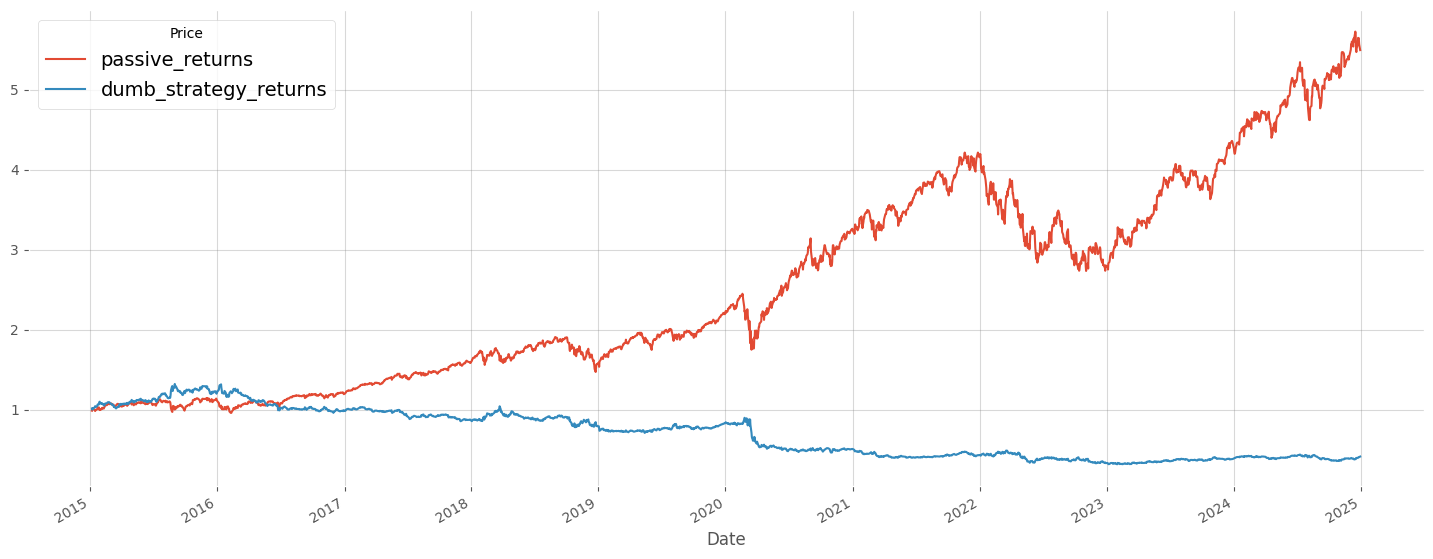

In [28]:
(
    qqq
    [["passive_returns", "dumb_strategy_returns"]]
    .dropna() # list-wise deletion
    .cumsum() # LOGARITHMIC cumulative summation
    .apply(np.exp) # brining the return values into original cumulative returns (for your stakeholders)
).plot(figsize = [18, 7]
      )

plt.show()

## <a id = "p2">2.</a>  <font color = "green"> Algorithmic Forex Trading with Momentum Strategy </font>  [back to table of contents](#top)

## Analytics Contexts

> Now, we have experienced the risks of relying on intuition for investment decisions. Instead, let's apply algorithmic decision-making based on the momentum rule (trend-following strategy).

> To assess performance, we must always consider "compared to what?" As a benchmark for evaluating our investment portfolio's performance, we will use a passive strategy that follows foreign exchange rates (buy-and-hold strategy).

### COLLECT & IMPORT

<!-- Daily
EXchange
USD
EUROS -->

In [29]:
usd_euro =\
(
    web # `pandas-datareader` library's submodule `data`
    .get_data_fred("DEXUSEU",   # daily exchange rate US EU
                   start = dt.datetime(2013, 11, 1),
                   end = dt.datetime(2024, 10, 31)
                  )
    .dropna()
                  # Daily
                  # EXchange
                  # US dollars to
                  # EUros
)

<a id="sma"></a>
### Let’s obtain a historical exchange rate between USD and EURO

> A list of all the exchange rates that FRED (Federal Reserve Bank of St. Louis) has daily data for can be found [HERE](http://research.stlouisfed.org/fred2/categories/94).

## WRANGLE

In [30]:
fx = usd_euro.copy()

In [31]:
fx =\
(
    fx
    .rename(columns = {"DEXUSEU": "price"}
           )
)

In [32]:
fx

,price
DATE,
2013-11-01,1.3488
2013-11-04,1.3516
2013-11-05,1.3470
2013-11-06,1.3530
2013-11-07,1.3390
...,...
2024-10-25,1.0813
2024-10-28,1.0819
2024-10-29,1.0798


## Set Look-Back Periods

> For detecting signals, we'd like to have noise-reduced price actions.

#### Shorter-term Simple `Moving Averages` (40 days)

In [33]:
fx["sma_40"] =\
(
    fx
    ["price"]
    .rolling(window = 40) # rolling 40 days
    .mean() # averages
)

In [34]:
(
    fx
    .isnull()
    .sum()
)

price      0
sma_40    39
dtype: int64

In [35]:
fx["sma_250"] =\
(
    fx
    ["price"]
    .rolling(window = 250) # rolling 40 days
    .mean() # averages
)

In [36]:
(
    fx
    .isnull()
    .sum()
)

price        0
sma_40      39
sma_250    249
dtype: int64

### VISUALIZE

#### With Grammar of Graphics Framework, using lets-plot

In [37]:
from lets_plot import *
LetsPlot.setup_html()

In [38]:
fx.columns

Index(['price', 'sma_40', 'sma_250'], dtype='object')

In [39]:
fx.head(1)

,price,sma_40,sma_250
DATE,,,
2013-11-01,1.3488,NaN,NaN


In [40]:
fx = fx.reset_index()
fx

,DATE,price,sma_40,sma_250
0,2013-11-01,1.3488,NaN,NaN
1,2013-11-04,1.3516,NaN,NaN
2,2013-11-05,1.3470,NaN,NaN
3,2013-11-06,1.3530,NaN,NaN
4,2013-11-07,1.3390,NaN,NaN
...,...,...,...,...
2743,2024-10-25,1.0813,1.101435,1.086845
2744,2024-10-28,1.0819,1.100767,1.086936
2745,2024-10-29,1.0798,1.100113,1.087007
2746,2024-10-30,1.0864,1.099665,1.087126


In [41]:
(
    ggplot(fx,
           aes(x = "DATE")
          )
    + geom_line(aes(y = "price"),
                color = "grey",
                alpha = 0.50
               )
    + geom_line(aes(y = "sma_40"),
                color = "red"
               )
    + geom_line(aes(y = "sma_250"),
                color = "darkgreen")
    + ggsize(1200, 400)
    + labs(title = "US/EU Exchange Rates, along with 40- and 250-day MAs",
           y = "US/EU Exchange Rates")
)

## Setting Positions

In [42]:
fx.head(3)

,DATE,price,sma_40,sma_250
0,2013-11-01,1.3488,NaN,NaN
1,2013-11-04,1.3516,NaN,NaN
2,2013-11-05,1.3470,NaN,NaN


> How to bring the column `DATE` back into index?

In [43]:
fx = fx.set_index("DATE")
fx # bring DATE column back to index

,price,sma_40,sma_250
DATE,,,
2013-11-01,1.3488,NaN,NaN
2013-11-04,1.3516,NaN,NaN
2013-11-05,1.3470,NaN,NaN
2013-11-06,1.3530,NaN,NaN
2013-11-07,1.3390,NaN,NaN
...,...,...,...
2024-10-25,1.0813,1.101435,1.086845
2024-10-28,1.0819,1.100767,1.086936
2024-10-29,1.0798,1.100113,1.087007


### Detect Momentum

In [44]:
fx["positions"] =\
(
    np
    .where(fx["sma_40"] > fx["sma_250"],
           1, -1)
       # buy, short-sell
)

In [45]:
(
    fx
    .isnull()
    .sum()
    # price ==> 0
    # sma_40 ==> 39
    # sma_250 ==> 249
    # positions ==> 0
)

price          0
sma_40        39
sma_250      249
positions      0
dtype: int64

In [46]:
fx = fx.dropna()

#### VISUALIZE

#### How about matplotlib, again

<Axes: xlabel='DATE'>

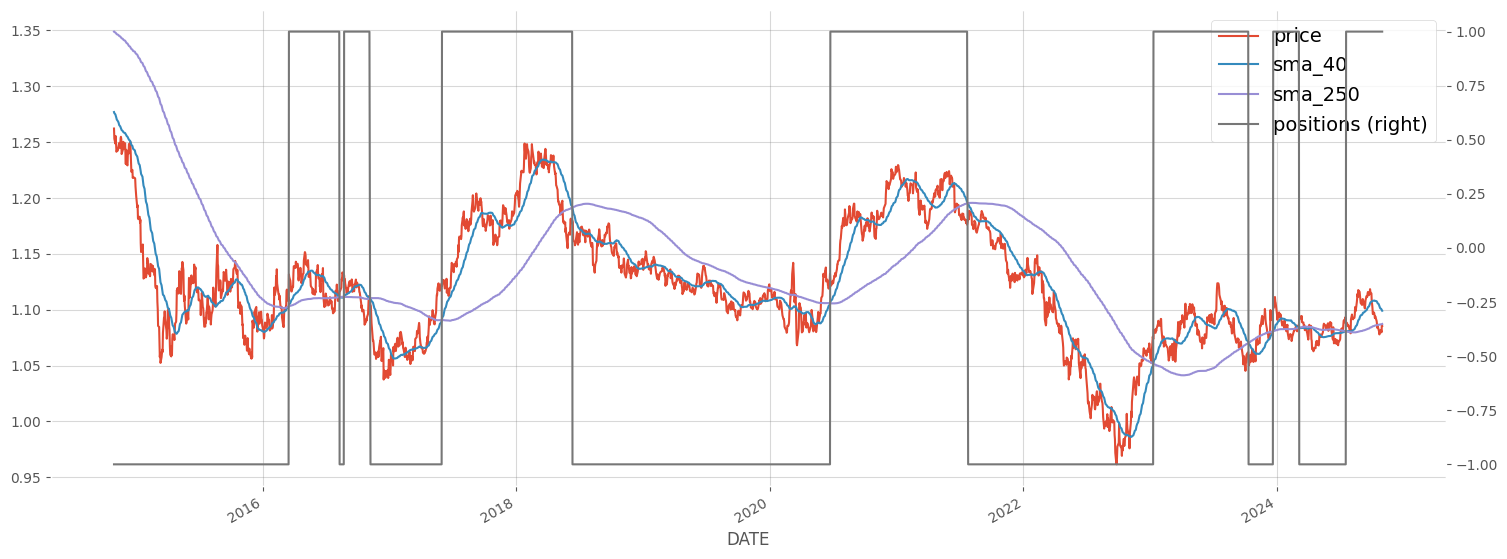

In [47]:
(
    fx
    .plot(secondary_y = "positions",
          figsize = [18, 7]
         )
)

### Passive Returns vs. Strategy (Momentum-based) Returns

In [48]:
fx["passive_following_returns"] =\
(
    np
    .log(fx["price"]
         /
         fx["price"].shift(1)
        )
)

fx.head(7)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/489961306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx["passive_following_returns"] =\


,price,sma_40,sma_250,positions,passive_following_returns
DATE,,,,,
2014-10-30,1.2622,1.276955,1.348969,-1,NaN
2014-10-31,1.2530,1.275965,1.348586,-1,-0.007316
2014-11-03,1.2487,1.274792,1.348174,-1,-0.003438
2014-11-04,1.2554,1.273807,1.347808,-1,0.005351
2014-11-05,1.2488,1.272755,1.347391,-1,-0.005271
2014-11-06,1.2414,1.271520,1.347001,-1,-0.005943
2014-11-07,1.2422,1.270235,1.346627,-1,0.000644


In [49]:
fx["our_strategy_returns"] =\
(
    fx["positions"].shift(1)
    *
    fx["passive_following_returns"]
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/2822092870.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx["our_strategy_returns"] =\


### VISUALIZE

### The Moment of Truth --> a.k.a., Blue Pill or Red Pill Test

In [50]:
fx.columns

Index(['price', 'sma_40', 'sma_250', 'positions', 'passive_following_returns',
       'our_strategy_returns'],
      dtype='object')

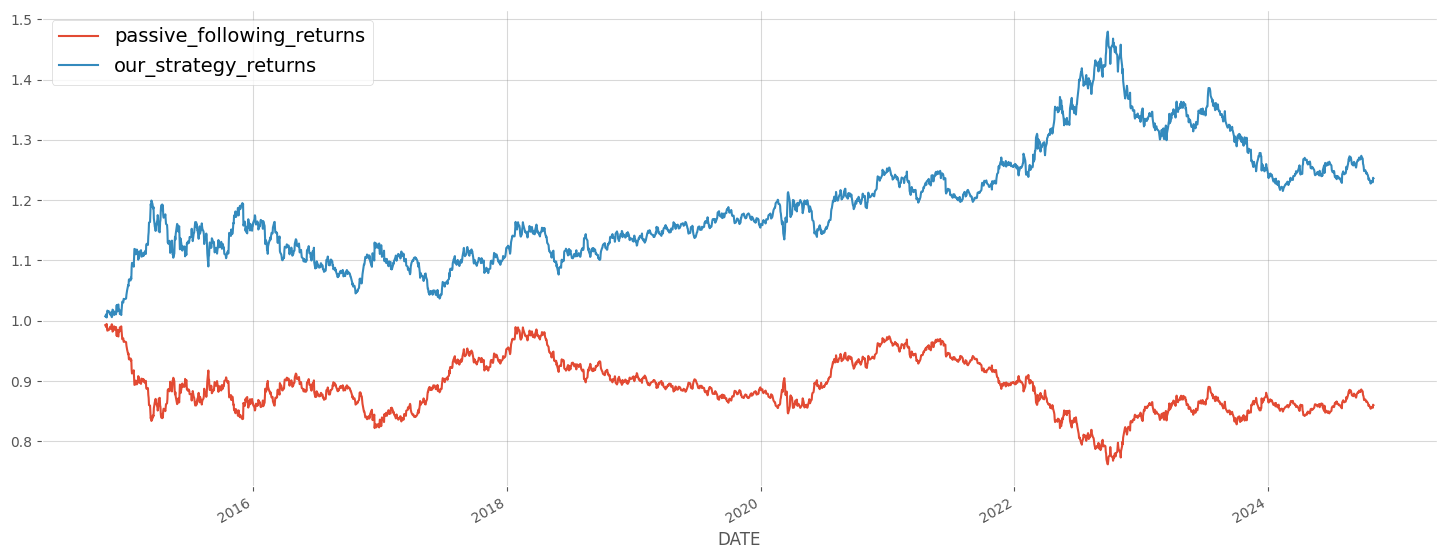

In [51]:
(
    fx
    [["passive_following_returns", "our_strategy_returns"]]
    .cumsum() # cumulative summation
    .apply(np.exp)
).plot(figsize = [18, 7]
      )

plt.show()

### Performance Metrics of Your Portfolio

In [52]:
fx.columns

Index(['price', 'sma_40', 'sma_250', 'positions', 'passive_following_returns',
       'our_strategy_returns'],
      dtype='object')

In [53]:
(
    fx
    [["passive_following_returns", "our_strategy_returns"]]
    .mean()
    * 252
)

passive_following_returns   -0.015214
our_strategy_returns         0.021379
dtype: float64

In [54]:
(
    fx
    [["passive_following_returns", "our_strategy_returns"]]
    .std()
    * 252
    ** 0.5
)

passive_following_returns    0.078934
our_strategy_returns         0.078928
dtype: float64

### `Draw-down` calculation

In [55]:
fx.columns

Index(['price', 'sma_40', 'sma_250', 'positions', 'passive_following_returns',
       'our_strategy_returns'],
      dtype='object')

In [56]:
fx["cumulative_strategy_returns"] =\
(
    fx["our_strategy_returns"] # this denotes logarithmic return
    .cumsum() # cumulative returns took logarithm
    .apply(np.exp) # bring the values back to the original simple cum. ret.
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/2285099588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx["cumulative_strategy_returns"] =\


In [57]:
fx.head(3)

,price,sma_40,sma_250,positions,passive_following_returns,our_strategy_returns,cumulative_strategy_returns
DATE,,,,,,,
2014-10-30,1.2622,1.276955,1.348969,-1,NaN,NaN,NaN
2014-10-31,1.2530,1.275965,1.348586,-1,-0.007316,0.007316,1.007342
2014-11-03,1.2487,1.274792,1.348174,-1,-0.003438,0.003438,1.010811


In [58]:
fx["maximum_gross_performance"] =\
(
    fx["cumulative_strategy_returns"]
    .cummax()
)

fx[["cumulative_strategy_returns", "maximum_gross_performance"]]

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/3464959570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fx["maximum_gross_performance"] =\


,cumulative_strategy_returns,maximum_gross_performance
DATE,,
2014-10-30,NaN,NaN
2014-10-31,1.007342,1.007342
2014-11-03,1.010811,1.010811
2014-11-04,1.005417,1.010811
2014-11-05,1.010730,1.010811
...,...,...
2024-10-25,1.231266,1.479424
2024-10-28,1.231950,1.479424
2024-10-29,1.229558,1.479424


<Axes: xlabel='DATE'>

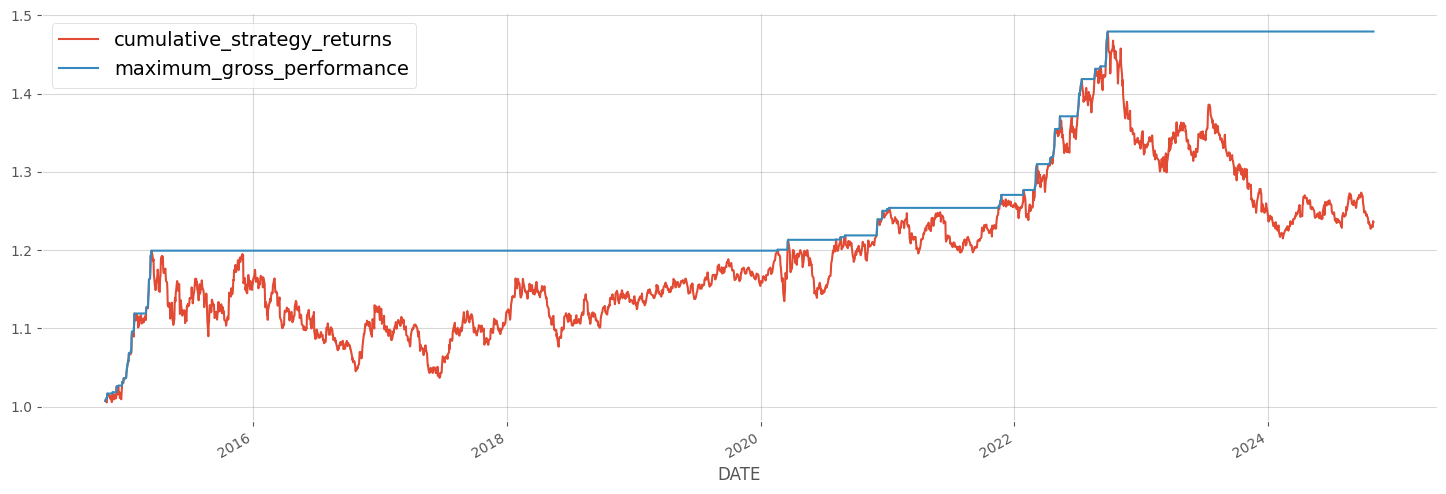

In [59]:
(
    fx[["cumulative_strategy_returns", "maximum_gross_performance"]]
    .dropna()
    .plot(figsize = [18, 6]
         )
)

> Recall the previous lesson: the maximum drawdown is then simply calculated as the maximum of the difference between the two relevant columns.

In [60]:
drawdown = fx["maximum_gross_performance"] - fx["cumulative_strategy_returns"]
# Team, this time, the drawdown values will be 
# either positive values
# or
#        zeros

# Previously (as you could see on the left side of the screen),
# we calculated drawdown as follows:
# drawdown = instrument_DF["price"] / rolling_maximum - 1.0
# The above drawdown returns either negative values or zeros

drawdown[ : 12]

DATE
2014-10-30         NaN
2014-10-31    0.000000
2014-11-03    0.000000
2014-11-04    0.005395
2014-11-05    0.000081
2014-11-06    0.000000
2014-11-07    0.000655
2014-11-10    0.000900
2014-11-12    0.003428
2014-11-13    0.005053
2014-11-14    0.006510
2014-11-17    0.002696
dtype: float64

In [61]:
drawdown.max()

np.float64(0.2643342953304997)

> In this case, the maximum drawdown is about __26__ percentage points.

> The longest drawdown period can be calculated using those dates at which the gross performance equals its cumulative maximum (namely, where a new maximum is set). Then the differences in days between all such dates are calculated, and the longest period comes out.

In [62]:
periods =\
(
    drawdown[drawdown == 0].index[1  :   ].to_pydatetime()
    -
    drawdown[drawdown == 0].index[   : -1].to_pydatetime()
)

periods

array([datetime.timedelta(days=3), datetime.timedelta(days=3),
       datetime.timedelta(days=15), datetime.timedelta(days=11),
       datetime.timedelta(days=1), datetime.timedelta(days=2),
       datetime.timedelta(days=3), datetime.timedelta(days=10),
       datetime.timedelta(days=1), datetime.timedelta(days=4),
       datetime.timedelta(days=6), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedelta(days=2),
       datetime.timedelta(days=3), datetime.timedelta(days=2),
       datetime.timedelta(days=1), datetime.timedelta(days=5),
       datetime.timedelta(days=2), datetime.timedelta(days=1),
       datetime.timedelta(days=6), datetime.timedelta(days=1),
       datetime.timedelta(days=34), datetime.timedelta(days=1),
       datetime.timedelta(days=3), datetime.timedelta(days=2),
       datetime.timedelta(days=1), datetime.timedelta(days=1),
       datetime.timedelta(days=3), datetime.timedelta(days=1),
       datetime.timedelta(days=1), datetime.timedel

In [63]:
periods.max()

datetime.timedelta(days=1804)

> The longest drawdown period lasts for __1,804__ days.

### Intraday stock prices

In [64]:
minute_by_minute_stock_price_data =\
(
    yf
    .download(tickers = "TSLA",
              interval = "1m",
              auto_adjust = True)
)

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['TSLA']: YFPricesMissingError('possibly delisted; no price data found  (period=1mo) (Yahoo error = "1m data not available for startTime=1756557134 and endTime=1759235534. Only 8 days worth of 1m granularity data are allowed to be fetched per request.")')


In [65]:
minute_by_minute_stock_price_data

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,


## <a id = "p3">3.</a>  <font color = "green"> Mean Reversion Strategy </font>  [back to table of contents](#top)

> Mean reversion means a tendency of asset prices to return to a trend path. Mean-reversion strategies are based on the opposite belief to momentum strategies—that is, if a financial instrument has performed too well relative to its trend, it is shorted, and vice versa. While time-series momentum strategies expect a positive correlation between returns, mean-reversion strategies anticipate a negative correlation.

    Mean-reversion strategy utilizes a simple moving average (SMA) as a proxy for a trend path. The key is to define a threshold for the distance between the current stock price and the SMA, which serves as a signal for a long or short position.

In [66]:
commodity_gold =\
(
    yf # yfinance module to extract financial market data from Yahoo!Finance
    .download("GDX", # Symbol --> GDX
              interval = "1d", # 
              period = "max") # 
    # ["Close"]
      [["Close"]]
    .droplevel("Ticker", # mute & unmute: ctrl + /
               axis = 1)
    # .droplevel("Price",
    #            axis = 1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/1712792051.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  .download("GDX", # Symbol --> GDX
[*********************100%***********************]  1 of 1 completed


In [67]:
commodity_gold

Price,Close
Date,
2006-05-22,31.823931
2006-05-23,32.447933
2006-05-24,31.217035
2006-05-25,32.755661
2006-05-26,32.952259
...,...
2025-09-23,74.230003
2025-09-24,72.320000
2025-09-25,73.129997


In [68]:
gold =\
(
    commodity_gold
    .copy()
)

In [69]:
gold

Price,Close
Date,
2006-05-22,31.823931
2006-05-23,32.447933
2006-05-24,31.217035
2006-05-25,32.755661
2006-05-26,32.952259
...,...
2025-09-23,74.230003
2025-09-24,72.320000
2025-09-25,73.129997


### Passive Returns (Buy-and-Hold Strategy; a.k.a. Grandma Strategy)

In [70]:
gold["passive_returns"] =\
(
    np
    .log(gold["Close"]
         /
         gold["Close"].shift(1)
        )
)

gold.head(10)

Price,Close,passive_returns
Date,,
2006-05-22,31.823931,NaN
2006-05-23,32.447933,0.019418
2006-05-24,31.217035,-0.038673
2006-05-25,32.755661,0.048112
2006-05-26,32.952259,0.005984
2006-05-30,32.627434,-0.009906
2006-05-31,33.208698,0.017658
2006-06-01,32.935162,-0.008271
2006-06-02,33.448048,0.015453


### 22 day moving averages of prices

In [71]:
gold["ma_22"] =\
(
    gold
    ["Close"]
    .rolling(window = 22)
    .mean()
)

In [72]:
(
    gold
    .isnull() # bool --> True being 1 or False being 0
    .sum()
)

Price
Close               0
passive_returns     1
ma_22              21
dtype: int64

### Detect Signals

### By Calculating the Distance of Prices (Daily Prices - 22MA Prices)

In [73]:
gold["distance"] = gold["Close"] - gold["ma_22"]
 # ["deviation"]    # daily noise      # more likely closer to inherent values of given asset
 # ["spread"]

### Set Threshold

#### <mark>Team, in the field practice, you always use relative threshold, but here, we'll use absolute threshold. </mark>

In [74]:
absolute_distance_threshold = 3

### Visualization of the Distance of the Prices

In [75]:
gold.head(3)

Price,Close,passive_returns,ma_22,distance
Date,,,,
2006-05-22,31.823931,NaN,NaN,NaN
2006-05-23,32.447933,0.019418,NaN,NaN
2006-05-24,31.217035,-0.038673,NaN,NaN


In [76]:
gold = gold.reset_index()
gold.head(3)

Price,Date,Close,passive_returns,ma_22,distance
0,2006-05-22,31.823931,NaN,NaN,NaN
1,2006-05-23,32.447933,0.019418,NaN,NaN
2,2006-05-24,31.217035,-0.038673,NaN,NaN


In [77]:
(
    ggplot(gold,
           aes(x = "Date",
               y = "distance")
          ) 
    + geom_line(color = "grey")
    + geom_hline(yintercept = absolute_distance_threshold,
                 color = "red")
    + geom_hline(yintercept = -absolute_distance_threshold,
                 color = "green") 
    + geom_hline(yintercept = 0,
                 color = "blue")
    + scale_y_continuous(breaks = np.arange(-10, 15, 5),
                         limits = [-10, 10]
                        )
    + ggsize(1600, 300)
    # + coord_flip()
)

### Set Positions

In [78]:
# Detect over-bought --> Price will go down --> Short-Sell

gold["positions"] =\
(
    np.where(gold["distance"] > absolute_distance_threshold,
             -1, np.nan)
)

# Detect over-sold --> price will go up --> Buy

gold["positions"] =\
(
    np.where(gold["distance"] < -absolute_distance_threshold,
             1, gold["positions"]
            ) # team, make sure to carry over the position that you have set above
)

# Detect Volatile Market --> it's too early to call --> Market Neutral Position (Hold)

gold["positions"] =\
(
    np.where(gold["distance"] * gold["distance"].shift(1) < 0,
             0, gold["positions"]
            )
)

In [79]:
gold["positions"] =\
(
    gold
    ["positions"]
    .ffill()        # fill all the NaN values forward. This will ensure we hold mean reversion to 0 at at least
)

<Axes: >

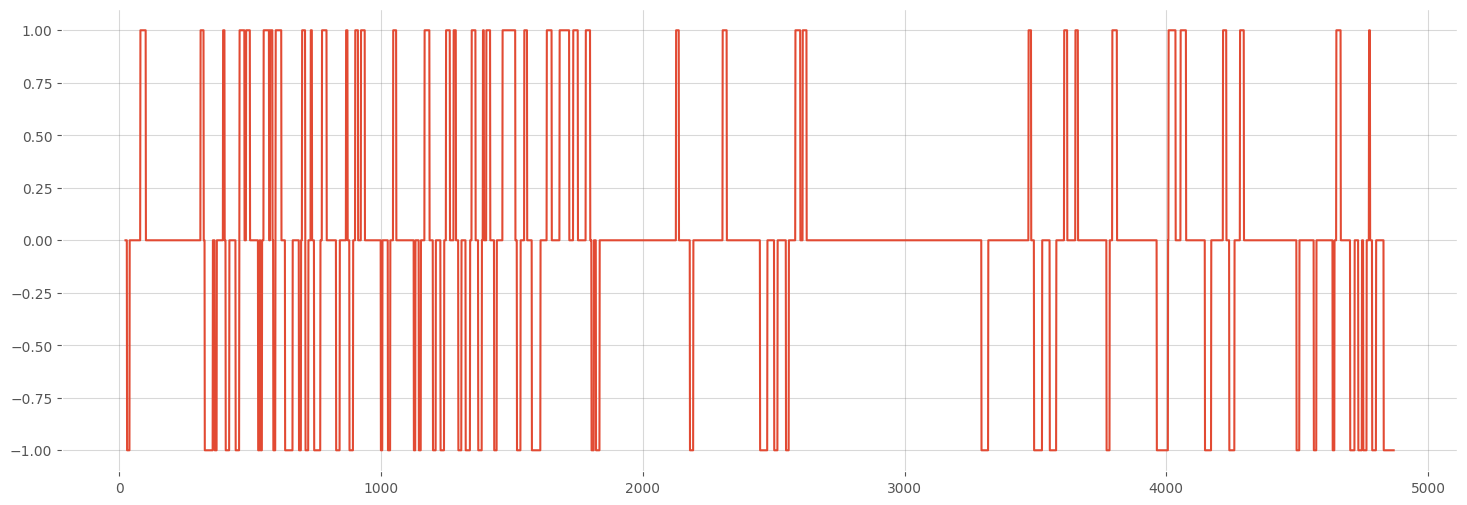

In [80]:
(
    gold["positions"]
    .iloc[22: ]
    .plot(figsize = [18, 6]
         )
)

### Strategy Returns 

In [81]:
gold[-22:]

Price,Date,Close,passive_returns,ma_22,distance,positions
4848,2025-08-28,61.330002,-0.002443,57.625909,3.704093,-1.0
4849,2025-08-29,63.169998,0.029560,58.143636,5.026362,-1.0
4850,2025-09-02,64.800003,0.025476,58.741818,6.058185,-1.0
4851,2025-09-03,65.199997,0.006154,59.321363,5.878634,-1.0
4852,2025-09-04,64.570000,-0.009710,59.759090,4.810909,-1.0
4853,2025-09-05,66.339996,0.027043,60.208181,6.131815,-1.0
4854,2025-09-08,67.239998,0.013475,60.655908,6.584089,-1.0
4855,2025-09-09,66.849998,-0.005817,61.060908,5.789090,-1.0
4856,2025-09-10,68.500000,0.024382,61.535454,6.964546,-1.0
4857,2025-09-11,69.760002,0.018227,62.084090,7.675912,-1.0


In [82]:
gold[22:]

Price,Date,Close,passive_returns,ma_22,distance,positions
22,2006-06-22,30.464811,-0.006154,30.912802,-0.447991,NaN
23,2006-06-23,31.011875,0.017798,30.847527,0.164348,0.0
24,2006-06-26,31.311066,0.009601,30.851801,0.459265,0.0
25,2006-06-27,30.328049,-0.031899,30.741455,-0.413406,0.0
26,2006-06-28,30.182732,-0.004803,30.615567,-0.432836,0.0
...,...,...,...,...,...,...
4865,2025-09-23,74.230003,-0.001346,66.768182,7.461821,-1.0
4866,2025-09-24,72.320000,-0.026068,67.320000,5.000000,-1.0
4867,2025-09-25,73.129997,0.011138,67.905000,5.224997,-1.0
4868,2025-09-26,74.680000,0.020974,68.499546,6.180455,-1.0


In [83]:
gold["mean_reversion_strategy_returns"] =\
(
    gold["positions"].shift(1)
    *
    gold["passive_returns"]
)

### Blue Pill vs. Red Pill Part 2:<mark>Our Mean Reversion Strategy vs. Passive Folling (Buy-and-Hold) of Gold Prices</mark>

In [84]:
gold.columns 

Index(['Date', 'Close', 'passive_returns', 'ma_22', 'distance', 'positions',
       'mean_reversion_strategy_returns'],
      dtype='object', name='Price')

In [85]:
gold = gold.set_index("Date")
gold

Price,Close,passive_returns,ma_22,distance,positions,mean_reversion_strategy_returns
Date,,,,,,
2006-05-22,31.823931,NaN,NaN,NaN,NaN,NaN
2006-05-23,32.447933,0.019418,NaN,NaN,NaN,NaN
2006-05-24,31.217035,-0.038673,NaN,NaN,NaN,NaN
2006-05-25,32.755661,0.048112,NaN,NaN,NaN,NaN
2006-05-26,32.952259,0.005984,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-09-23,74.230003,-0.001346,66.768182,7.461821,-1.0,0.001346
2025-09-24,72.320000,-0.026068,67.320000,5.000000,-1.0,0.026068
2025-09-25,73.129997,0.011138,67.905000,5.224997,-1.0,-0.011138


<Axes: xlabel='Date'>

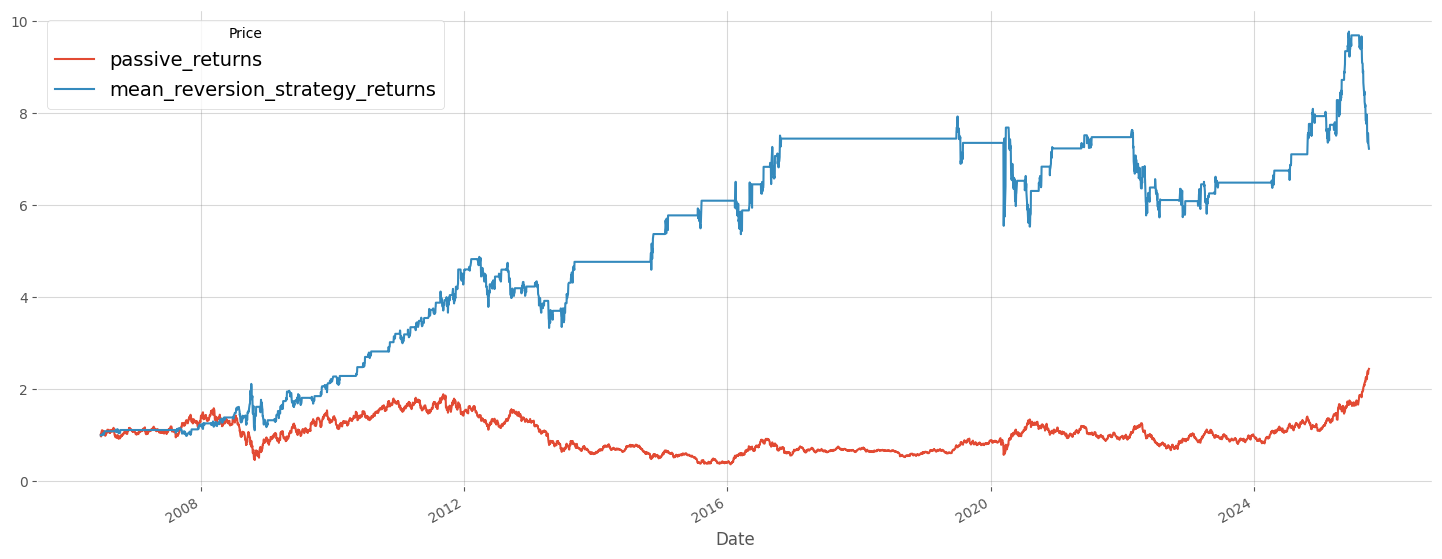

In [86]:
(
    gold[["passive_returns", "mean_reversion_strategy_returns"]]
    .dropna()
    .cumsum() # cumulative logarithmic returns
    .apply(np.exp) # bring the log returns to simple returns (for easier understanding of your stakeholders)
).plot(figsize = [18, 7]
      )

### Simulation

> Simulation is a valuable tool in computational business analytics for a variety of reasons. First, simulation can be used to model complex business processes, allowing analysts to identify areas for improvement and test different scenarios to see how they might affect outcomes. This can help businesses make more informed decisions and develop strategies to increase efficiency and profitability.

> Simulation can also be used to test the performance of different systems or products under various conditions. By simulating how these systems or products might perform in the real world, businesses can identify potential issues or weaknesses and make improvements before launching them.

> Additionally, simulation can be used to generate large amounts of data for analysis, which can be particularly useful when working with limited data sets or trying to predict outcomes in complex systems. Overall, simulation can be a powerful tool for businesses looking to optimize their operations and make data-driven decisions.

> An awesome application: How about a `geometric Brownian motion`?

$$
    S_t = S_{t_1} e^{(\mu - \frac{\sigma^2}{2})\Delta t + \sigma \sqrt{\Delta t} Z}
$$

In [96]:
# Financial Time-series in Pandas

drift = 0.04
vol = 0.50

# Parameters of Financial Markets

def create_financial_time_series(Rows,
                                 Columns,
                                 freq = "1 min"
                                 ):

    Rows = int(Rows)
    Columns = int(Columns)

    COLUMNS = ["Stock_ID %d"  % i for i in range(Columns)
              ]
    
    INDEX =\
    (
        pd
        .date_range("2025-09-30",
                    periods = Rows,
                    freq = freq)
    )

    Timedelta =\
    (
        (INDEX[1] - INDEX[0]) 
        / 
        pd.Timedelta(value = "365D")
    )

    # Geometric Brownian Motion

    GB =\
    (
        np
        .exp(np
             .cumsum(
                     (drift - 0.5 * vol ** 2) * Timedelta + 
                      vol * np.sqrt(Timedelta) * np.random.standard_normal((Rows, Columns)
                                                                           ),
                      axis = 0
                    )
            )
    )

    GB = GB / GB[0] * 221 # normalization of intial price
    
# Team, now we are ready to generate synthetic DatFrame (of Financial Markets)


    DF=\
    (
        pd
        .DataFrame(GB,
                   columns = COLUMNS,
                   index = INDEX)
    )

    return DF

<Axes: >

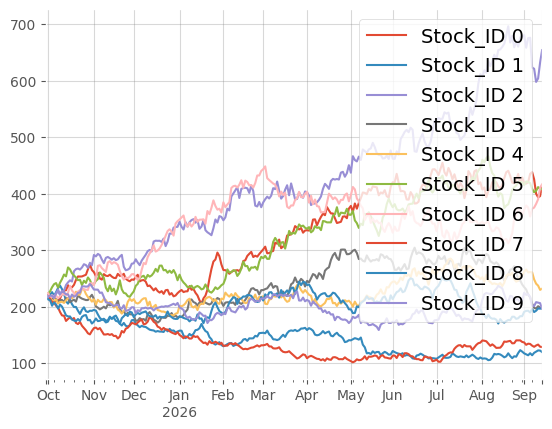

In [128]:
create_financial_time_series(Rows=250, 
                             Columns=10, 
                             freq="B").plot()

## Mean-Reversion with Bollinger Bands (2 standard deviations threshold)

### COLLECT & IMPORT

In [129]:
instrument = "NFLX"

price = "Close"

data =\
(
    yf
    .download([instrument],
              start = pd.Timestamp(2011, 5, 1),
              end = pd.Timestamp(2024, 4, 30)
             )
    [[price]]
    .droplevel("Ticker",
               axis = 1)
)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_33337/2641880166.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  .download([instrument],
[*********************100%***********************]  1 of 1 completed


In [130]:
data

Price,Close
Date,
2011-05-02,33.884285
2011-05-03,33.034286
2011-05-04,32.741428
2011-05-05,32.901428
2011-05-06,32.781429
...,...
2024-04-23,577.750000
2024-04-24,555.119995
2024-04-25,564.799988


### WRANGLE

#### 42-day moving averages

In [90]:
data["ma_42"] =\
(
    data
    [price]
    .rolling(42)
    .mean()
)

### MODEL

In [91]:
data["ma_42_2_std"] =\
(
    data
    [price]
    .rolling(42)
    .std()
    * 2
)

### Upper-bound Band

In [92]:
data["upper_bound"] = data["Close"] + data["ma_42_2_std"]

### Lower-bound Band

In [93]:
data["lower_bound"] = data["Close"] - data["ma_42_2_std"]

### VISUALIZE

In [94]:
data = data.reset_index()
data.head(3)

Price,Date,Close,ma_42,ma_42_2_std,upper_bound,lower_bound
0,2011-05-02,33.884285,NaN,NaN,NaN,NaN
1,2011-05-03,33.034286,NaN,NaN,NaN,NaN
2,2011-05-04,32.741428,NaN,NaN,NaN,NaN


In [95]:
(
    ggplot(data,
           aes(x = "Date")
          )
    + geom_line(aes(y = "Close"),
                color = "grey",
                alpha = 0.70)
    + geom_line(aes(y = "ma_42"),
                color = "blue",
                alpha = 0.80)
    + geom_line(aes(y = "upper_bound"),
                color = "red",
                alpha = 0.50
               )
    + geom_line(aes(y = "lower_bound"),
                color = "red",
                alpha = 0.50)
    + ggsize(1600, 800)
)

## <a id = "p5">5. </a> <font color = "green"> What We Have Learned </font>  [back to table of contents](#top)

    Revision Pointer 1.

    Revision Pointer 2.

    Revision Pointer 3.

> `Thank you for working with the script, Team 👍`